In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 

import beberapa library yang bakalan kita pakek nantinya

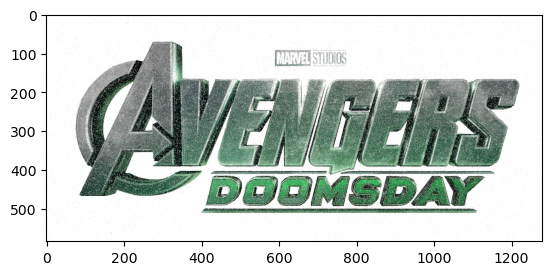

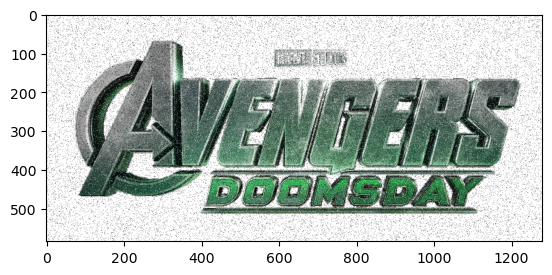

In [5]:
img_plt = plt.imread('doomsday.png')

plt.imshow(img_plt)
plt.show()

img_cv = cv2.imread('doomsday.png')

img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.show()

ambil gambar doomsday lalu simpan di variabel img_plt, lalu convert ke dalam gambar RGB pakek cv.Color

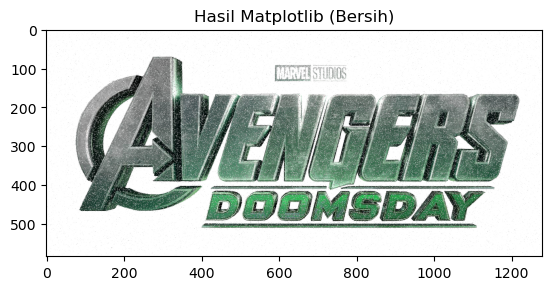

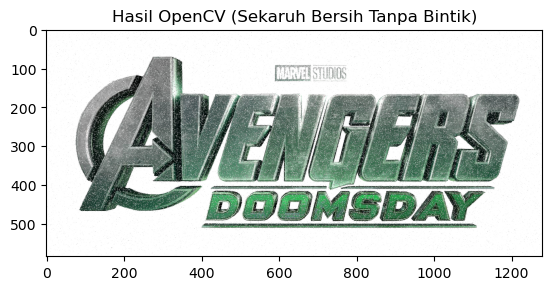

In [21]:
img_plt = plt.imread('doomsday.png')
plt.imshow(img_plt)
plt.title("Hasil Matplotlib (Bersih)")
plt.show()

img_cv = cv2.imread('doomsday.png', cv2.IMREAD_UNCHANGED)

if img_cv.shape[2] == 4:
    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGRA2RGBA)
else:
    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)

img_rgb_clean = img_rgb / 255.0

plt.imshow(img_rgb_clean)
plt.title("Hasil OpenCV (Sekaruh Bersih Tanpa Bintik)")
plt.show()

plt.imread membaca PNG sebagai array RGBA (4 channel) dengan nilai float 0.0–1.0. Karena matplotlib membaca channel secara langsung tanpa konversi, warna tampil benar dan background transparan ditangani otomatis.IMREAD_UNCHANGED membaca semua channel termasuk alpha sehingga shape menjadi (H, W, 4). Pengecekan shape[2] == 4 memastikan apakah alpha ada. Jika ya, konversi BGRA menjadi RGBA hanya menukar urutan channel agar sesuai format matplotlib. Lalu dibagi 255.0 untuk normalisasi ke float 0.0–1.0 sama seperti output plt.imread.

In [37]:
def fungsi_dua(image, new_width, new_height):    
    old_height, old_width = image.shape[:2]     
    resized_image = np.zeros((new_height, new_width), dtype=np.uint8)     
    for i in range(new_height):         
        for j in range(new_width):             
            x = int(j * old_width / new_width)             
            y = int(i * old_height / new_height)            
            resized_image[i, j] = image[y, x]     
    return resized_image 

def convolution(img, kernel):
    size     = kernel.shape[0]
    pad_size = size // 2
    padded   = np.pad(img, pad_size, mode='constant')
    canvas   = np.zeros_like(img, dtype=np.float32)
    height, width = img.shape
    for i in range(height):
        for j in range(width):
            region       = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return canvas

def edge(img, kernelx, kernely):

    gx = convolution(img, kernelx) 

    gy = convolution(img, kernely) 

    canvas = np.abs(gx) + np.abs(gy) 
    
    canvas = canvas * 255.0 / np.max(canvas) 

    return np.clip(canvas, 0, 255).astype(np.uint8) 

def threshold_manual(img, nilai_threshold):
    h, w = img.shape
    hasil = np.zeros((h, w), dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            if img[i,j] > nilai_threshold:
                hasil[i,j] = 255
            else:
                hasil[i,j] = 0
    return hasil

def metode_satu(image,kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height//2
    hasil = np.zeros((height, width))
    for i in range(center, height-center):
        for j in range(center, width-center):
            if image[i,j] == 255:
                for k in range(k_height):
                    for l in range(k_width):
                        if kernel[k,l] == 1:
                            hasil[i+k-center,j+l-center] =255
                        else:
                            if hasil[i,j] !=255:
                                hasil[i,j] = 0
    return hasil



def gaussian_kernel(size=5, sigma=1.0):
    k = size // 2
    kernel = np.zeros((size, size), dtype=np.float32)
    for i in range(size):
        for j in range(size):
            x, y = i - k, j - k
            kernel[i, j] = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    return kernel / np.sum(kernel)

def hapus_noise(img):
    h, w = img.shape
    hasil = np.zeros_like(img)
    for i in range(1, h - 1):
        for j in range(1, w - 1):
            if img[i, j] == 255:
                tetangga = [
                    img[i-1, j], img[i+1, j],
                    img[i, j-1], img[i, j+1],
                    img[i-1, j-1], img[i-1, j+1],
                    img[i+1, j-1], img[i+1, j+1]
                ]
                if any(t == 255 for t in tetangga):
                    hasil[i, j] = 255
    return hasil

def metode_empat(img, kernel, iterasi=1):
    hasil = img.copy()
    for _ in range(iterasi):
        hasil = metode_satu(hasil, kernel)
    return hasil

Rangkaian fungsi ini dirancang untuk pengolahan citra digital, mulai dari mengubah ukuran gambar skala keabuan (grayscale) menggunakan metode proporsional nearest neighbor (fungsi_dua) hingga pembersihan titik putih terisolasi yang tidak memiliki tetangga (hapus_noise). Proses manipulasi piksel dilakukan lewat teknik konvolusi matriks ber-padding nol (convolution) serta pembuatan filter pengabur otomatis (gaussian_kernel). Selain itu, sistem ini mampu mendeteksi garis tepi berdasarkan akumulasi gradien horizontal dan vertikal (edge), memisahkan objek lewat binerisasi hitam-putih (threshold_manual), serta mempertebal sekaligus menyambung garis-garis tepi yang terputus menggunakan operasi morfologi dilasi, baik dalam skala tunggal (metode_satu) maupun secara berulang (metode_empat).

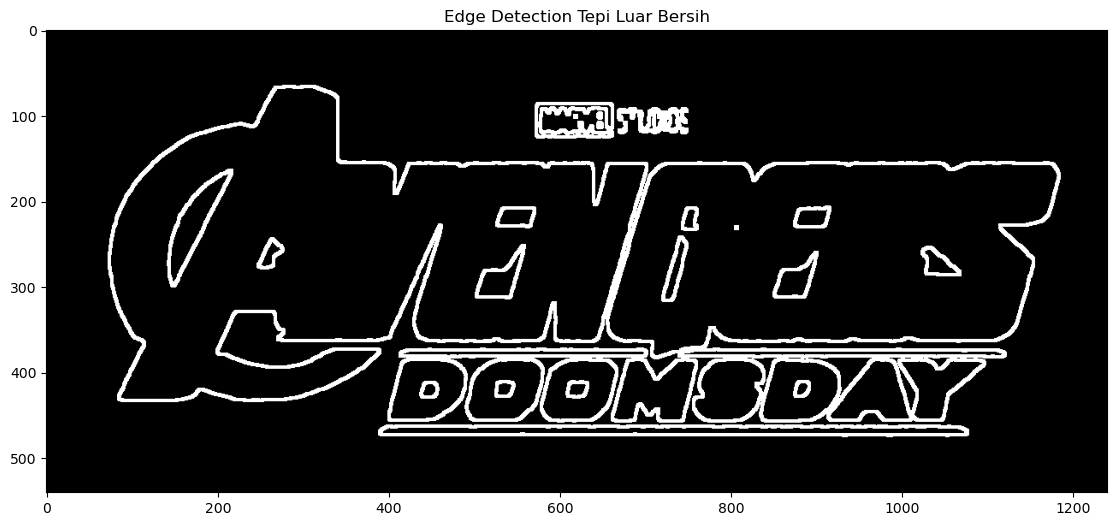

In [ ]:
def hapus_noise_dalam(img, min_tetangga=3):
    h, w = img.shape
    hasil = img.copy()
    for i in range(1, h-1):
        for j in range(1, w-1):
            if img[i, j] == 255:
                tetangga_putih = (
                    int(img[i-1,j]==255) + int(img[i+1,j]==255) +
                    int(img[i,j-1]==255) + int(img[i,j+1]==255) +
                    int(img[i-1,j-1]==255) + int(img[i-1,j+1]==255) +
                    int(img[i+1,j-1]==255) + int(img[i+1,j+1]==255)
                )
                if tetangga_putih < min_tetangga:
                    hasil[i, j] = 0
    return hasil

img_cv = cv2.imread('doomsday.png', cv2.IMREAD_UNCHANGED)
alpha  = img_cv[:, :, 3].astype(np.float32)

gauss      = gaussian_kernel(size=7, sigma=3.0)  
alpha_blur = np.clip(convolution(alpha, gauss), 0, 255).astype(np.uint8)

mask = np.zeros_like(alpha_blur)
mask[alpha_blur > 128] = 255 

mask_resized = fungsi_dua(mask, 1240, 540)

sobelX = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=np.float32)
sobelY = np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=np.float32)

hasil_edge   = edge(mask_resized, sobelX, sobelY)
hasil_thresh = threshold_manual(hasil_edge, nilai_threshold=30)

kernel_dil   = np.array([[1,1,1],[1,1,1],[1,1,1]], dtype=np.float32)
hasil_dilasi = metode_satu(hasil_thresh, kernel_dil)

hasil_final = hapus_noise_luar(hasil_dilasi)
hasil_final = hapus_noise_luar(hasil_final)

hasil_final = hapus_noise_dalam(hasil_final, min_tetangga=2) 
hasil_final = hapus_noise_dalam(hasil_final, min_tetangga=2)

plt.figure(figsize=(14, 6))
plt.imshow(hasil_final, cmap='gray')
plt.title("Edge Detection Tepi Luar Bersih")
plt.show()

Kode di atas mengimplementasikan pipeline pengolahan citra digital untuk mendeteksi garis tepi (edge) objek secara bersih dan tajam dari saluran alpha gambar doomsday.png. Alur proses dimulai dari ekstraksi dan pengaburan saluran alpha menggunakan filter Gaussian, diikuti binerisasi (thresholding) serta pengubahan ukuran gambar menjadi 1240x540 piksel. Selanjutnya, tepian objek diekstrak menggunakan Operator Sobel, dipertebal dengan operasi morfologi dilasi, dan dibersihkan secara intensif dari bintik pengganggu (noise) menggunakan fungsi eliminasi piksel terisolasi (hapus_noise_luar dan hapus_noise_dalam), hingga menghasilkan visualisasi garis tepi luar yang mulus dan bebas bercak hitam-putih.

In [51]:
def fungsi_dua_rgb(image, new_width, new_height):
    old_height, old_width = image.shape[:2]
    resized = np.zeros((new_height, new_width, 3), dtype=np.uint8)
    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)
            resized[i, j] = image[y, x]
    return resized

fungsi_dua_rgb, Fungsi ini adalah versi RGB dari fungsi_dua. Setiap pixel (i,j) di gambar baru dipetakan ke koordinat (y,x) di gambar asli secara proporsional. Karena image[y,x] pada array RGB mengembalikan array [R,G,B], ketiga channel langsung tersalin sekaligus dalam satu operasi.

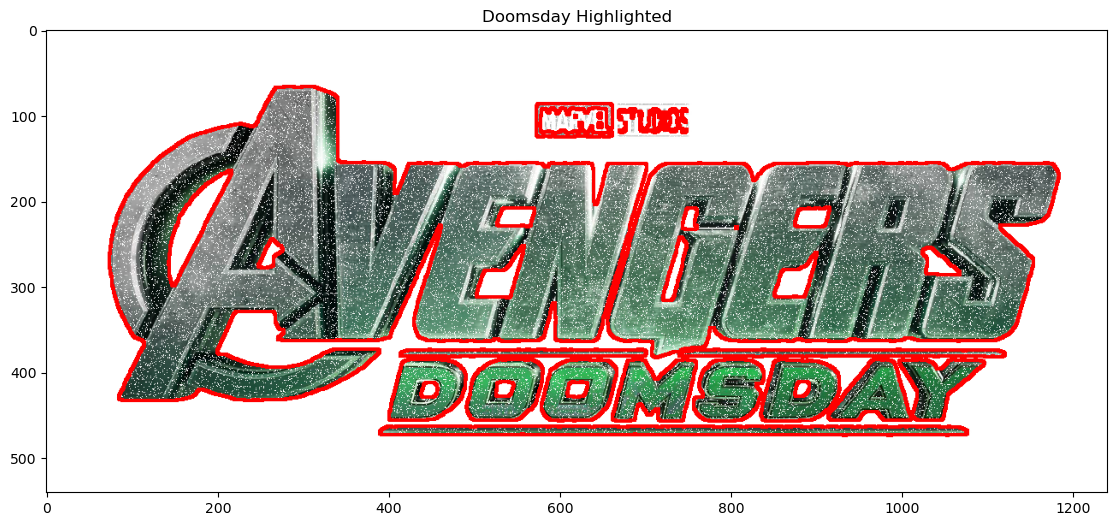

In [ ]:
img_cv     = cv2.imread('doomsday.png', cv2.IMREAD_UNCHANGED)
bgr        = img_cv[:, :, :3]
alpha      = img_cv[:, :, 3]

alpha_f    = alpha.astype(np.float32) / 255.0
background = np.ones_like(bgr, dtype=np.float32) * 255
bgr_f      = bgr.astype(np.float32)
alpha_3ch  = np.stack([alpha_f]*3, axis=2)
composited = (bgr_f * alpha_3ch + background * (1 - alpha_3ch)).astype(np.uint8)
img_rgb    = cv2.cvtColor(composited, cv2.COLOR_BGR2RGB)

img_resized = fungsi_dua_rgb(img_rgb, 1240, 540)

alpha_blur  = np.clip(convolution(alpha.astype(np.float32), gaussian_kernel(size=7, sigma=3.0)), 0, 255).astype(np.uint8)
mask        = np.zeros_like(alpha_blur)
mask[alpha_blur > 128] = 255
mask_resized = fungsi_dua(mask, 1240, 540)

sobelX = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=np.float32)
sobelY = np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=np.float32)

hasil_edge   = edge(mask_resized, sobelX, sobelY)
hasil_thresh = threshold_manual(hasil_edge, nilai_threshold=30)
kernel_dil   = np.array([[1,1,1],[1,1,1],[1,1,1]], dtype=np.float32)
hasil_dilasi = metode_satu(hasil_thresh, kernel_dil)
hasil_tepi   = hapus_noise_luar(hasil_dilasi)
hasil_tepi   = hapus_noise_luar(hasil_tepi)
hasil_tepi   = hapus_noise_dalam(hasil_tepi, min_tetangga=2)
hasil_tepi   = hapus_noise_dalam(hasil_tepi, min_tetangga=2)

hasil_overlay = img_resized.copy()
tepi_mask = hasil_tepi == 255
hasil_overlay[tepi_mask, 0] = 255
hasil_overlay[tepi_mask, 1] = 0
hasil_overlay[tepi_mask, 2] = 0

plt.figure(figsize=(14, 6))
plt.imshow(hasil_overlay)
plt.title("Doomsday Highlighted")
plt.show()

kode ini memproses gambar doomsday.png dengan menggabungkan objek BGR ke latar belakang putih murni menggunakan teknik alpha blending, lalu mengubah ukurannya menjadi 1240x540 piksel. Secara paralel, saluran alpha diekstraksi, dihaluskan dengan filter Gaussian, dan diubah menjadi masker biner untuk mendeteksi garis tepi menggunakan Operator Sobel. Setelah melewati proses penebalan lewat dilasi morfologi serta pembersihan bintik pengganggu (noise) menggunakan fungsi hapus_noise_luar dan hapus_noise_dalam, hasil deteksi tepi bersih tersebut ditumpuk kembali (overlay) ke atas gambar utama dengan mengubah warnanya menjadi merah solid ([255, 0, 0]) sebagai efek sorotan (highlight).

KESIMPULAN
Melalui kombinasi filter Gaussian untuk penghalusan, operator Sobel untuk ekstraksi tepi, serta operasi morfologi (dilasi dan pembersihan noise berlapis), kode ini berhasil memisahkan objek utama dari latar belakang transparannya, membersihkan kotoran piksel yang mengganggu, dan menghasilkan visualisasi akhir berupa tepi luar objek yang tersorot tegas dengan warna merah di atas gambar RGB yang bersih.